In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from src import get_brats_loaders

# 1. Loader initialization
train_loader, val_loader = get_brats_loaders(
    csv_path="../data_inventory.csv", 
    batch_size=2, 
    cache_rate=0.4
)

print(f"Loaders ready. Train batches: {len(train_loader)}")

c:\Users\alecz\AppData\Local\Programs\Python\Python313\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Loading dataset: 100%|██████████| 27/27 [00:18<00:00,  1.49it/s]

Loaders ready. Train batches: 540


Rozpoczynam podgląd 3 iteracji...


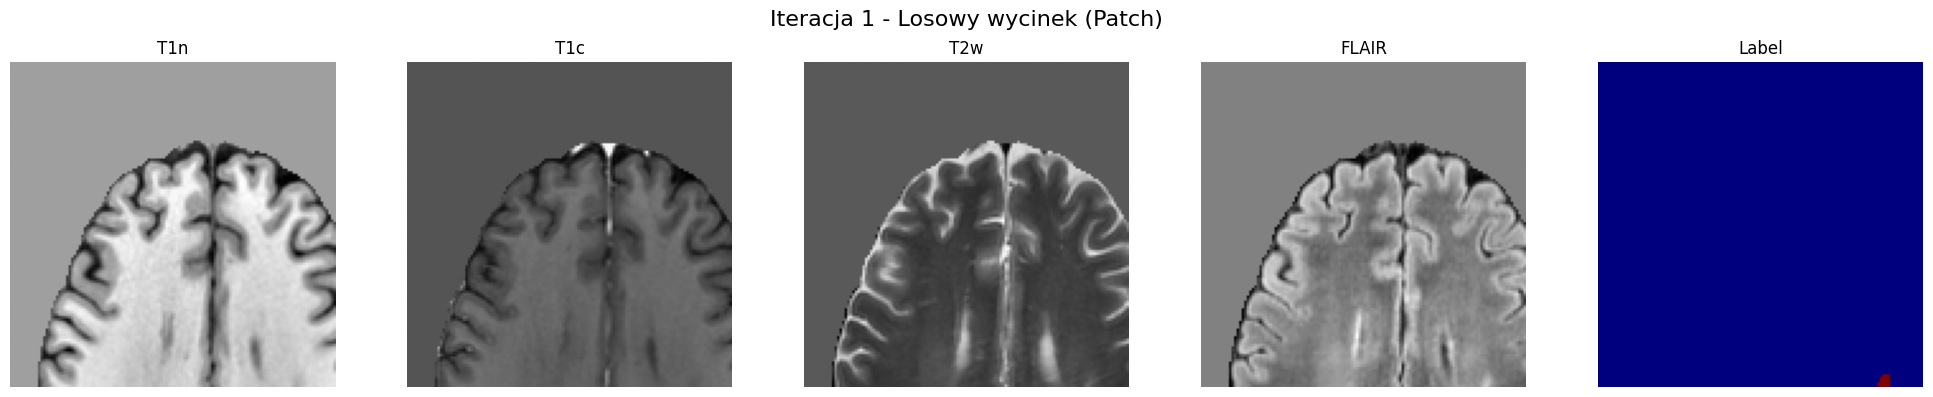

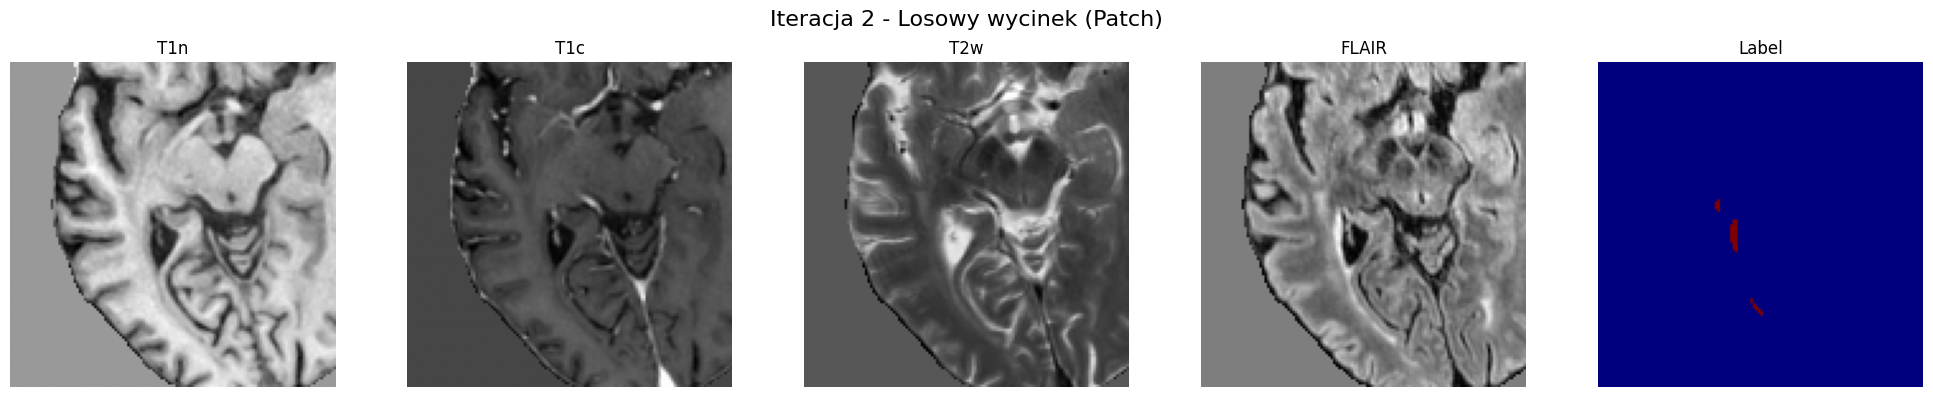

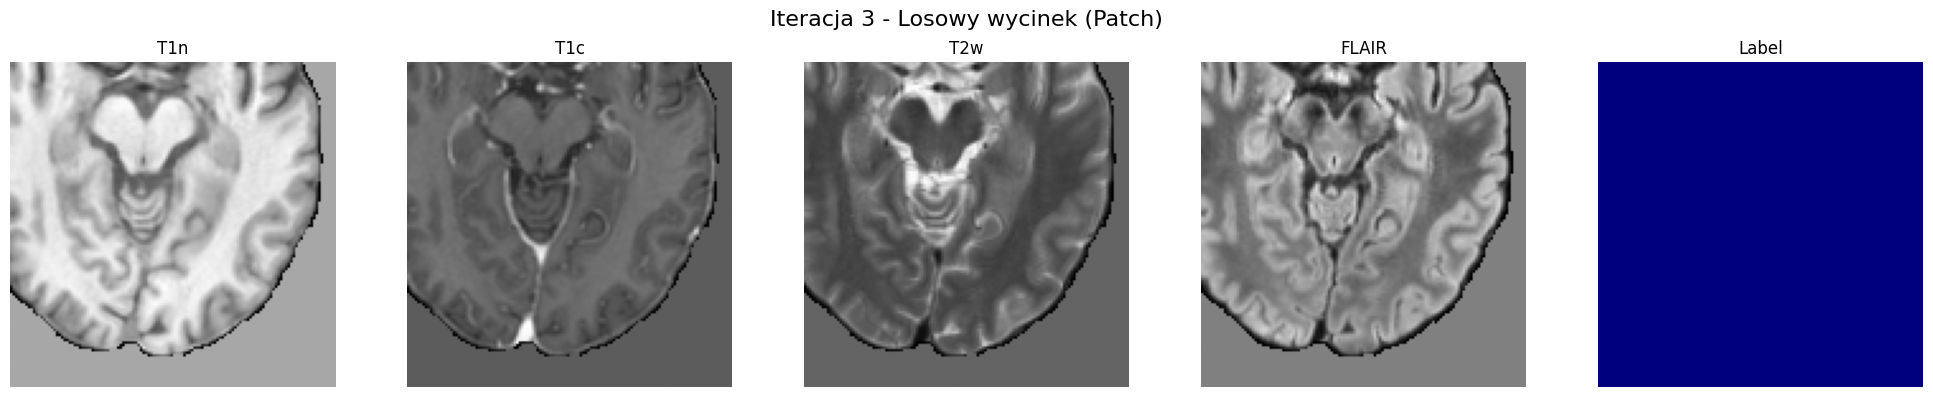

Podgląd zakończony.


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Ustalamy, ile iteracji chcemy zobaczyć
num_iterations = 3
modalities = ["T1n", "T1c", "T2w", "FLAIR", "Label"]
slice_idx = 64 # Środkowy przekrój kostki 128x128x128

print(f"Rozpoczynam podgląd {num_iterations} iteracji...")

for i, batch in enumerate(train_loader):
    if i >= num_iterations:
        break
    
    # Wyciągamy dane z aktualnego batcha
    images = batch["image"] # [Batch, 4, 128, 128, 128]
    labels = batch["label"] # [Batch, 1, 128, 128, 128]
    
    # Bierzemy pierwszego pacjenta z tej paczki [indeks 0]
    img_tensor = images[0].cpu().numpy()
    lbl_tensor = labels[0].cpu().numpy()
    
    # Tworzymy rząd wykresów dla tej iteracji
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Iteracja {i+1} - Losowy wycinek (Patch)", fontsize=16)
    
    for m in range(4):
        # Obracamy o 90 stopni, żeby mózg był "pionowo"
        axes[m].imshow(np.rot90(img_tensor[m, :, :, slice_idx]), cmap='gray')
        axes[m].set_title(modalities[m])
        axes[m].axis('off')

    # Maska (Label)
    axes[4].imshow(np.rot90(lbl_tensor[0, :, :, slice_idx]), cmap='jet')
    axes[4].set_title(modalities[4])
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85) # Robimy miejsce na tytuł
    plt.show()

print("Podgląd zakończony.")